In [ ]:
# FUNGSI KODE: Mengimpor semua library yang diperlukan untuk SVM, preprocessing, dan evaluasi

import pandas as pd  # Untuk mengolah dan memanipulasi data dalam bentuk tabel (DataFrame)
import numpy as np  # Untuk operasi matematika dan array numerik
from sklearn.model_selection import train_test_split, GridSearchCV
# train_test_split: membagi dataset menjadi data latih dan data uji
# GridSearchCV: mencari kombinasi hyperparameter terbaik untuk model

from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder: mengubah data kategorikal menjadi angka
# StandardScaler: menstandarkan fitur agar memiliki mean 0 dan standar deviasi 1

from sklearn.impute import SimpleImputer
# SimpleImputer: mengisi nilai yang hilang (missing value) pada dataset

from sklearn.svm import SVC
# SVC: algoritma Support Vector Classifier untuk tugas klasifikasi

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
# accuracy_score: menghitung akurasi prediksi
# precision_score: menghitung presisi
# recall_score: menghitung recall
# f1_score: kombinasi presisi & recall (harmonic mean)
# classification_report: ringkasan metrik klasifikasi
# confusion_matrix: matriks yang menunjukkan prediksi benar/salah

import matplotlib.pyplot as plt  # Untuk membuat grafik dan visualisasi
import seaborn as sns  # Untuk visualisasi data yang lebih menarik & informatif


In [ ]:
# FUNGSI KODE: Membaca dataset Chronic Kidney Disease Stage 1–5 yang telah diupload

df = pd.read_csv("/content/updated_ckd_dataset_with_stages.csv")

print("Jumlah data:", df.shape)
df.head()
# row_54 = df.iloc[[54]]
# df_dropped = df.drop(54)
# df_new = pd.concat([row_54, df_dropped], ignore_index=True)
# df_new.head()

Jumlah data: (4000, 23)


,serum_creatinine,gfr,bun,serum_calcium,ana,c3_c4,hematuria,oxalate_levels,urine_ph,blood_pressure,...,smoking,alcohol,painkiller_usage,family_history,weight_changes,stress_level,months,cluster,ckd_pred,ckd_stage
0,0.683683,32.946784,7.553739,10.039896,0,138.204989,0,2.878164,7.864308,115.224217,...,yes,daily,no,yes,stable,low,10,5,CKD,3
1,3.809044,32.685035,141.347494,8.330543,1,24.282343,1,4.767639,4.920015,130.143900,...,yes,daily,no,yes,loss,moderate,1,2,CKD,3
2,1.143827,2.079805,15.979104,9.419229,0,163.970666,0,1.818613,6.188115,98.026072,...,no,daily,no,no,stable,moderate,4,6,CKD,5
3,4.804657,109.871407,53.307333,7.556631,1,71.056846,1,4.051686,5.278607,142.166650,...,no,never,yes,yes,stable,high,9,2,CKD,1
4,4.920235,42.214590,134.182157,7.289379,1,23.384639,1,3.240920,4.862923,151.962572,...,no,occasionally,yes,no,gain,high,7,2,CKD,3


In [ ]:
import pandas as pd

# Load dataset
data = pd.read_csv("updated_ckd_dataset_with_stages.csv")

# Menampilkan 5 data teratas
print("===== HEAD DATASET =====")
print(df.head())

# Menampilkan informasi struktur & tipe data
print("\n===== INFO DATASET =====")
print(df.info())


===== HEAD DATASET =====
   serum_creatinine         gfr         bun  serum_calcium  ana       c3_c4  \
0          0.683683   32.946784    7.553739      10.039896    0  138.204989   
1          3.809044   32.685035  141.347494       8.330543    1   24.282343   
2          1.143827    2.079805   15.979104       9.419229    0  163.970666   
3          4.804657  109.871407   53.307333       7.556631    1   71.056846   
4          4.920235   42.214590  134.182157       7.289379    1   23.384639   

   hematuria  oxalate_levels  urine_ph  blood_pressure  ... smoking  \
0          0        2.878164  7.864308      115.224217  ...     yes   
1          1        4.767639  4.920015      130.143900  ...     yes   
2          0        1.818613  6.188115       98.026072  ...      no   
3          1        4.051686  5.278607      142.166650  ...      no   
4          1        3.240920  4.862923      151.962572  ...      no   

        alcohol  painkiller_usage family_history weight_changes stress_le

In [ ]:
# Menampilkan statistik deskriptif dari dataset
# Fungsi print() digunakan untuk menampilkan teks ke layar
print("===== STATISTIK DESKRIPTIF DATASET =====")

# data.describe() digunakan untuk menghitung statistik deskriptif
# secara otomatis untuk setiap kolom numerik dalam dataset.
# Statistik yang ditampilkan meliputi:
# - count : jumlah data (tidak termasuk nilai kosong/NaN)
# - mean  : nilai rata-rata
# - std   : standar deviasi (mengukur sebaran data)
# - min   : nilai minimum
# - 25%   : kuartil pertama (Q1)
# - 50%   : median (Q2)
# - 75%   : kuartil ketiga (Q3)
# - max   : nilai maksimum

print(data.describe())

===== STATISTIK DESKRIPTIF DATASET =====
       serum_creatinine          gfr          bun  serum_calcium          ana  \
count       4000.000000  4000.000000  4000.000000    4000.000000  4000.000000   
mean           1.551423    51.735449    39.346088       8.537530     0.300000   
std            1.217478    34.389322    42.495106       1.403631     0.458315   
min            0.500273     0.021317     7.000920       5.002407     0.000000   
25%            0.758924    20.263808    11.632573       7.810761     0.000000   
50%            0.995209    50.054933    16.296667       8.982200     0.000000   
75%            2.065796    80.258482    67.090486       9.583627     1.000000   
max            4.994009   119.923482   149.999395      10.199344     1.000000   

             c3_c4    hematuria  oxalate_levels     urine_ph  blood_pressure  \
count  4000.000000  4000.000000     4000.000000  4000.000000     4000.000000   
mean    109.757723     0.300000        2.624439     6.394566      119

In [ ]:
# Cek jumlah missing value tiap kolom
missing_per_column = data.isnull().sum()

print("===== JUMLAH MISSING VALUE PER KOLOM =====")
print(missing_per_column)

===== JUMLAH MISSING VALUE PER KOLOM =====
serum_creatinine     0
gfr                  0
bun                  0
serum_calcium        0
ana                  0
c3_c4                0
hematuria            0
oxalate_levels       0
urine_ph             0
blood_pressure       0
physical_activity    0
diet                 0
water_intake         0
smoking              0
alcohol              0
painkiller_usage     0
family_history       0
weight_changes       0
stress_level         0
months               0
cluster              0
ckd_pred             0
ckd_stage            0
dtype: int64


In [ ]:
# Cek jumlah data duplikat
jumlah_duplikat = data.duplicated().sum()

print("===== JUMLAH DATA DUPLIKAT =====")
print("Total data duplikat:", jumlah_duplikat)

===== JUMLAH DATA DUPLIKAT =====
Total data duplikat: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Salin data agar data asli tidak berubah
data_encoded = data.copy()

# Deteksi kolom kategorik
kolom_kategorik = data_encoded.select_dtypes(include=['object']).columns

print("===== KOLOM KATEGORIK SEBELUM ENCODING =====")
print(kolom_kategorik)

# Proses Label Encoding
le = LabelEncoder()
for col in kolom_kategorik:
    data_encoded[col] = le.fit_transform(data_encoded[col])

print("\n===== DATASET SETELAH ENCODING =====")
print(data_encoded.head())


===== KOLOM KATEGORIK SEBELUM ENCODING =====
Index(['physical_activity', 'diet', 'smoking', 'alcohol', 'painkiller_usage',
       'family_history', 'weight_changes', 'stress_level', 'ckd_pred'],
      dtype='object')

===== DATASET SETELAH ENCODING =====
   serum_creatinine         gfr         bun  serum_calcium  ana       c3_c4  \
0          0.683683   32.946784    7.553739      10.039896    0  138.204989   
1          3.809044   32.685035  141.347494       8.330543    1   24.282343   
2          1.143827    2.079805   15.979104       9.419229    0  163.970666   
3          4.804657  109.871407   53.307333       7.556631    1   71.056846   
4          4.920235   42.214590  134.182157       7.289379    1   23.384639   

   hematuria  oxalate_levels  urine_ph  blood_pressure  ...  smoking  alcohol  \
0          0        2.878164  7.864308      115.224217  ...        1        0   
1          1        4.767639  4.920015      130.143900  ...        1        0   
2          0        1.81861

In [ ]:
# FUNGSI KODE: Membersihkan data bertipe string agar konsisten (lowercase & strip)

str_cols = df.select_dtypes(include=['object']).columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip().str.lower())


In [ ]:
print(df.columns)


Index(['serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana', 'c3_c4',
       'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure',
       'physical_activity', 'diet', 'water_intake', 'smoking', 'alcohol',
       'painkiller_usage', 'family_history', 'weight_changes', 'stress_level',
       'months', 'cluster', 'ckd_pred', 'ckd_stage'],
      dtype='object')


**Kode tersebut digunakan untuk memisahkan fitur (X) dan label (y), yang merupakan tahap wajib dalam proses machine learning. Variabel X berisi seluruh atribut input (fitur medis), sedangkan y berisi kolom ckd_stage sebagai label yang akan diprediksi oleh algoritma SVM.**
⤵

In [ ]:
target_col = "ckd_stage"   # kolom label CKD Stage
X = df.drop(columns=[target_col])
y = df[target_col]


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Pisahkan fitur dan target
X = data_encoded.drop('ckd_stage', axis=1)
y = data_encoded['ckd_stage']

# Tampilkan data sebelum normalisasi
print("===== DATA SEBELUM NORMALISASI =====")
print(X.head())

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Jadikan DataFrame kembali
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n===== DATA SETELAH NORMALISASI =====")
print(X_scaled_df.head())


===== DATA SEBELUM NORMALISASI =====
   serum_creatinine         gfr         bun  serum_calcium  ana       c3_c4  \
0          0.683683   32.946784    7.553739      10.039896    0  138.204989   
1          3.809044   32.685035  141.347494       8.330543    1   24.282343   
2          1.143827    2.079805   15.979104       9.419229    0  163.970666   
3          4.804657  109.871407   53.307333       7.556631    1   71.056846   
4          4.920235   42.214590  134.182157       7.289379    1   23.384639   

   hematuria  oxalate_levels  urine_ph  blood_pressure  ...  water_intake  \
0          0        2.878164  7.864308      115.224217  ...      2.314979   
1          1        4.767639  4.920015      130.143900  ...      2.250649   
2          0        1.818613  6.188115       98.026072  ...      2.542343   
3          1        4.051686  5.278607      142.166650  ...      2.640812   
4          1        3.240920  4.862923      151.962572  ...      3.148921   

   smoking  alcohol  pain

In [ ]:
# FUNGSI KODE: Membagi data menjadi 80% training dan 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Dari total 15 parameter default pada algoritma SVM, hanya tiga parameter yang dioptimasi menggunakan Grid Search, yaitu C, gamma, dan kernel. Hal ini karena ketiga parameter tersebut merupakan parameter inti yang paling berpengaruh terhadap performa model SVM. Parameter lainnya bersifat pendukung dan tidak memberikan pengaruh signifikan terhadap akurasi model.**bold text:**
⤵

In [ ]:
# ===========================================================
# 1. MEMBUAT MODEL SVM (Baseline) – BELUM DILATIH
# ===========================================================
model_svm = SVC(kernel='linear', random_state=42)
# Pada baris ini model SVM dibuat dengan kernel linear.
# Model BELUM belajar apa pun, baru dibuat (instansiasi).


# ===========================================================
# 2. MELATIH MODEL SVM (TRAINING)
# ===========================================================
model_svm.fit(X_train, y_train)
# Pada baris ini model SVM BELAJAR dari data X_train dan y_train.
# fit() = training proses klasifikasi sebenarnya.
# Model mempelajari pola fitur → untuk memprediksi CKD Stage.


# ===========================================================
# 3. MEMPREDIKSI DATA UJI (TESTING)
# ===========================================================
y_pred_baseline = model_svm.predict(X_test)
# predict() digunakan untuk membuat prediksi CKD stage pada data X_test.
# Ini adalah hasil klasifikasi model baseline.


# ===========================================================
# 4. MELIHAT PARAMETER MODEL DEFAULT SVM
# ===========================================================
from sklearn.svm import SVC
import pandas as pd

model = SVC()
# Baris ini membuat model SVM baru (tanpa training) hanya untuk melihat parameter default.

# Convert parameter ke tabel agar mudah dibaca
params = pd.DataFrame(model.get_params().items(), columns=["Parameter", "Value"])
print(params)

# Menampilkan beberapa parameter inti SVM
print("Kernel :", model.kernel)
print("C      :", model.C)
print("Gamma  :", model.gamma)


                  Parameter  Value
0                         C    1.0
1                break_ties  False
2                cache_size    200
3              class_weight   None
4                     coef0    0.0
5   decision_function_shape    ovr
6                    degree      3
7                     gamma  scale
8                    kernel    rbf
9                  max_iter     -1
10              probability  False
11             random_state   None
12                shrinking   True
13                      tol  0.001
14                  verbose  False
Kernel : rbf
C      : 1.0
Gamma  : scale


In [ ]:
# FUNGSI KODE: Mengevaluasi performa model dengan accuracy, precision, recall, F1-score, dan confusion matrix

def evaluate(y_true, y_pred, title="Model"):
    print(f"\n=== Evaluasi {title} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted', zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted', zero_division=0))
    print("F1-Score :", f1_score(y_true, y_pred, average='weighted', zero_division=0))

    # Menampilkan classification report lengkap (per kelas)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # membuat confusion matrix nya
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted") # sumbu X prediksi
    plt.ylabel("Actual") # sumbu Y label asli
    plt.show()



=== Evaluasi SVM (Baseline) ===
Accuracy : 0.9675
Precision: 0.9693215732622683
Recall   : 0.9675
F1-Score : 0.9675893392660891

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.98      0.95      0.96       100
           2       0.95      0.99      0.97       208
           3       1.00      0.94      0.97       191
           4       0.92      1.00      0.96       146
           5       1.00      0.95      0.97       132

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



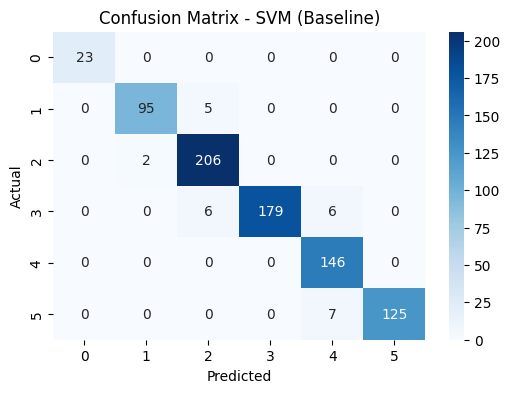

In [ ]:
# FUNGSI KODE: Mengevaluasi model SVM sebelum optimasi Grid Search

evaluate(y_test, y_pred_baseline, "SVM (Baseline)")


In [ ]:
# FUNGSI KODE: Mencari parameter terbaik SVM (C, gamma, kernel) menggunakan Grid Search CV

# Daftar kombinasi parameter yang akan diuji oleh Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Membuat objek GridSearchCV
grid = GridSearchCV(
    estimator=SVC(),            # Model yang akan dioptimasi
    param_grid=param_grid,      # Daftar parameter yang dicoba
    cv=5,                       # 5-fold cross validation
    scoring='accuracy',         # Metric yang dinilai adalah akurasi
    n_jobs=-1                   # Gunakan semua core CPU agar proses cepat
)

# Menjalankan Grid Search (menguji semua kombinasi parameter)
grid.fit(X_train, y_train)

print("\n=== Best Parameters dari Grid Search ===")
print(grid.best_params_)



=== Best Parameters dari Grid Search ===
{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}


In [ ]:
# FUNGSI KODE: Mengambil model SVM terbaik hasil Grid Search

best_svm = grid.best_estimator_ # Mengambil model SVM dengan parameter terbaik (C, gamma, kernel)
# yang sudah ditemukan dan dilatih oleh Grid Search.
y_pred_opt = best_svm.predict(X_test) # Menggunakan model terbaik tersebut untuk memprediksi data uji


=== Evaluasi SVM After Grid Search Optimization ===
Accuracy : 0.98375
Precision: 0.9838887734374615
Recall   : 0.98375
F1-Score : 0.9837701577164721

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.96      0.98      0.97       100
           2       0.99      0.98      0.98       208
           3       0.98      0.99      0.99       191
           4       0.98      0.98      0.98       146
           5       1.00      0.98      0.99       132

    accuracy                           0.98       800
   macro avg       0.98      0.99      0.99       800
weighted avg       0.98      0.98      0.98       800



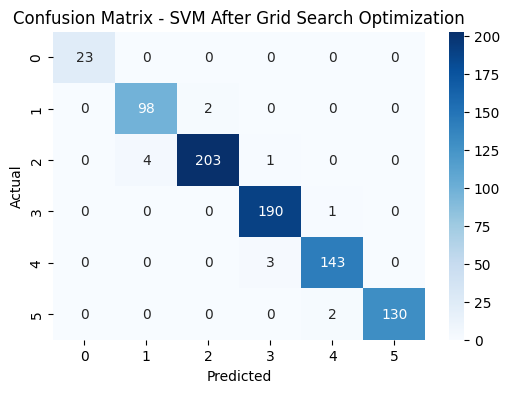

In [ ]:
# FUNGSI KODE: Mengukur performa model SVM hasil optimasi Grid Search

evaluate(y_test, y_pred_opt, "SVM After Grid Search Optimization")


In [ ]:
# FUNGSI KODE: Menampilkan jumlah Stage 0–5 dengan format rapi
stage_counts = df['ckd_stage'].value_counts().sort_index()

for stage, count in stage_counts.items():
    print(f"Stage {stage}: {count} data")


Stage 0: 125 data
Stage 1: 545 data
Stage 2: 1004 data
Stage 3: 866 data
Stage 4: 794 data
Stage 5: 666 data


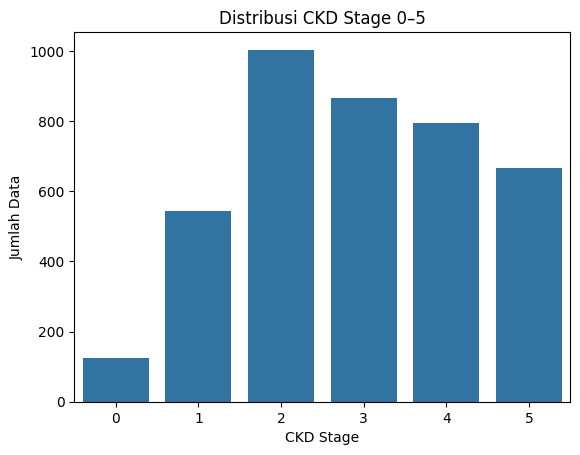

In [ ]:
# FUNGSI KODE: Visualisasi jumlah CKD Stage 1–5

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='ckd_stage')
plt.title("Distribusi CKD Stage 0–5")
plt.xlabel("CKD Stage")
plt.ylabel("Jumlah Data")
plt.show()


In [ ]:
# Pastikan kolom ckd_stage menjadi integer
df['ckd_stage'] = df['ckd_stage'].astype(str).str.strip().astype(int)

# Buat kolom pemisah: 0 = Non-CKD, 1 = CKD
df['label_binary'] = df['ckd_stage'].apply(lambda x: 0 if x == 0 else 1)

# Pisahkan Non-CKD
non_ckd = df[df['label_binary'] == 0]

# Pisahkan CKD
ckd = df[df['label_binary'] == 1]

# Tampilkan jumlah masing-masing
print("Jumlah NON-CKD:", non_ckd.shape)
print("Jumlah CKD    :", ckd.shape)


Jumlah NON-CKD: (125, 24)
Jumlah CKD    : (3875, 24)


In [ ]:
df['ckd_stage'] = df['ckd_stage'].astype(str).str.strip().astype(int)

df['label_binary'] = df['ckd_stage'].apply(
    lambda x: 0 if x == 0 else 1
)


In [ ]:
count_data = df['label_binary'].value_counts()
count_data


,count
label_binary,
1,3875
0,125


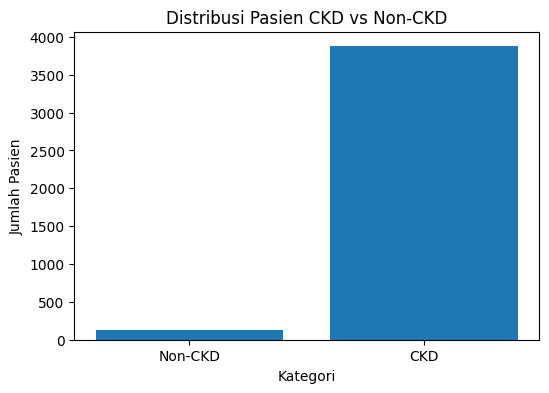

In [ ]:
import matplotlib.pyplot as plt

# Label
labels = ['Non-CKD', 'CKD']
values = [count_data[0], count_data[1]]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Distribusi Pasien CKD vs Non-CKD")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Pasien")
plt.show()


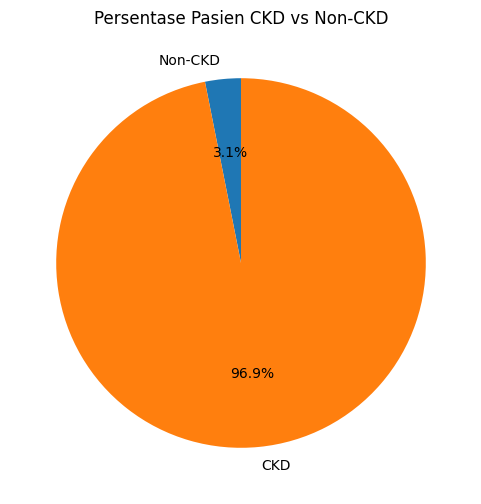

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Persentase Pasien CKD vs Non-CKD")
plt.show()


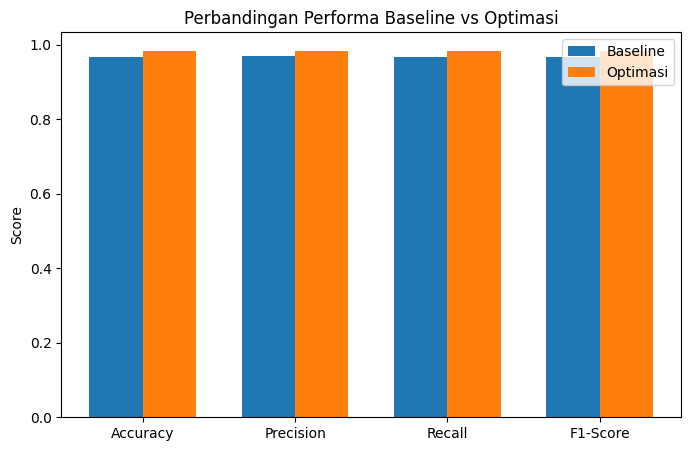

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_base = accuracy_score(y_test, y_pred_baseline)
prec_base = precision_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
recall_base = recall_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
f1_base = f1_score(y_test, y_pred_baseline, average='weighted', zero_division=0)

acc_opt = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt, average='weighted', zero_division=0)
recall_opt = recall_score(y_test, y_pred_opt, average='weighted', zero_division=0)
f1_opt = f1_score(y_test, y_pred_opt, average='weighted', zero_division=0)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [acc_base, prec_base, recall_base, f1_base]
optimized_scores = [acc_opt, prec_opt, recall_opt, f1_opt]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, optimized_scores, width, label='Optimasi')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Perbandingan Performa Baseline vs Optimasi')
plt.legend()
plt.show()


In [ ]:
pip install flask numpy pandas scikit-learn joblib

In [ ]:
X = data[['gfr', 'serum_creatinine', 'blood_pressure']]
y = data['ckd_stage']


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='accuracy')

In [ ]:
for col in X.columns:
    if X[col].dtype == "object":
        print(col, X[col].unique())


In [ ]:
mapping = {
    "physical_activity": {
        "low": 1,
        "weekly": 2,
        "daily": 3
    },
    "diet": {
        "poor": 1,
        "moderate": 2,
        "good": 3
    }
}


In [ ]:
# =========================
# IMPORT
# =========================
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from google.colab import files

# =========================
# DAFTAR FITUR (21 FITUR)
# =========================
feature_names = [
    'serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana',
    'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph',
    'blood_pressure', 'physical_activity', 'diet', 'water_intake',
    'smoking', 'alcohol', 'painkiller_usage', 'family_history',
    'weight_changes', 'stress_level', 'months', 'cluster'
]

# =========================
# DATA
# =========================
X = data[feature_names]
y = data['ckd_stage']

# =========================
# KONVERSI KATEGORIK → NUMERIK
# =========================
X = X.apply(lambda col: col.astype('category').cat.codes
            if col.dtype == 'object' else col)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# TRAIN MODEL
# =========================
model = SVC(kernel='rbf')
model.fit(X_scaled, y)

print("MODEL MENGHARAPKAN FITUR:", model.n_features_in_)

# =========================
# SIMPAN FILE
# =========================
joblib.dump(model, 'model_svm.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

# =========================
# DOWNLOAD KE LAPTOP
# =========================
files.download('model_svm.pkl')
files.download('scaler.pkl')
files.download('feature_names.pkl')


MODEL MENGHARAPKAN FITUR: 21


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>